In [1]:
!pip install Faker -q

import numpy as np
import pandas as pd
from faker import Faker

fake = Faker()

# Reproducibility
np.random.seed(42)
Faker.seed(42)

N = 2000

print("Number of students:", N)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 40.2 MB/s eta 0:00:00
Number of students: 2000


Student Demographics

In [2]:
student_ids = [f"STU{10000 + i}" for i in range(N)]

names = [fake.name() for _ in range(N)]

ages = np.random.randint(17, 25, size=N)

gender = np.random.choice(
    ["Male", "Female", "Other"],
    size=N,
    p=[0.48, 0.48, 0.04]
)

print("Demographic data generated.")

Demographic data generated.


Generate academic/behavioral variables

In [3]:
attendance = np.random.normal(
    loc=78,
    scale=12,
    size=N
)

attendance = np.clip(attendance, 35, 100)

In [4]:
study_hours = np.random.normal(
    loc=18,
    scale=7,
    size=N
)

study_hours = np.clip(
    study_hours,
    2,
    45
)

In [5]:
previous_grade = (
    35
    + 0.35 * attendance
    + 0.8 * study_hours
    + np.random.normal(0, 8, N)
)

previous_grade = np.clip(
    previous_grade,
    30,
    95
)

Generate assignment marks

In [6]:
assignment_marks = (
    0.45 * previous_grade
    + 0.8 * study_hours
    + np.random.normal(0, 7, N)
)

assignment_marks = np.clip(
    assignment_marks,
    20,
    100
)

Generate internal assessment marks

In [7]:
internal_marks = (
    0.30 * previous_grade
    + 0.25 * attendance
    + 0.35 * assignment_marks
    + np.random.normal(0, 6, N)
)

internal_marks = np.clip(
    internal_marks,
    20,
    100
)

Parental support

In [8]:
parental_support = np.random.choice(
    ["Low", "Medium", "High"],
    size=N,
    p=[0.15, 0.55, 0.30]
)

Online classes

In [9]:
online_classes = np.random.choice(
    ["Yes", "No"],
    size=N,
    p=[0.55, 0.45]
)

Extracurricular activities

In [10]:
extracurricular = np.random.poisson(
    lam=1.5,
    size=N
)

extracurricular = np.clip(
    extracurricular,
    0,
    5
)

the final examination mark

In [11]:
parental_score = np.select(
    [
        parental_support == "Low",
        parental_support == "Medium",
        parental_support == "High"
    ],
    [
        0,
        3,
        6
    ]
)

online_score = np.where(
    online_classes == "Yes",
    2,
    0
)

In [12]:
final_exam = (
    0.20 * previous_grade
    + 0.15 * attendance
    + 0.15 * study_hours
    + 0.20 * assignment_marks
    + 0.25 * internal_marks
    + parental_score
    + online_score
    + np.random.normal(0, 7, N)
)

final_exam = np.clip(
    final_exam,
    0,
    100
)

Create the DataFrame

In [13]:
df_synthetic = pd.DataFrame({
    "StudentID": student_ids,
    "Name": names,
    "Age": ages,
    "Gender": gender,
    "AttendancePct": np.round(attendance, 2),
    "StudyHoursPerWeek": np.round(study_hours, 2),
    "PreviousGrade": np.round(previous_grade, 2),
    "AssignmentMarks": np.round(assignment_marks, 2),
    "InternalAssessmentMarks": np.round(internal_marks, 2),
    "OnlineClasses": online_classes,
    "ExtracurricularActivities": extracurricular,
    "ParentalSupport": parental_support,
    "FinalExamMarks": np.round(final_exam, 2)
})

print("Dataset shape:", df_synthetic.shape)

display(df_synthetic.head())

Dataset shape: (2000, 13)


,StudentID,Name,Age,Gender,AttendancePct,StudyHoursPerWeek,PreviousGrade,AssignmentMarks,InternalAssessmentMarks,OnlineClasses,ExtracurricularActivities,ParentalSupport,FinalExamMarks
0,STU10000,Allison Hill,23,Male,90.72,3.75,91.99,33.84,62.97,Yes,1,Medium,63.78
1,STU10001,Noah Rhodes,20,Female,85.40,18.33,71.25,42.83,48.57,Yes,0,Low,49.94
2,STU10002,Angie Henderson,21,Female,86.20,16.26,67.35,46.31,57.16,No,2,Medium,61.95
3,STU10003,Daniel Wagner,23,Female,61.61,6.29,67.47,40.79,44.76,No,1,Medium,43.33
4,STU10004,Cristian Santos,19,Female,92.54,20.83,67.44,62.36,69.36,No,0,Medium,66.48


checking whether our synthetic relationships make sense

In [14]:
display(
    df_synthetic.describe(include="all").T
)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
StudentID,2000,2000,STU11983,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Name,2000,1972,Jessica Smith,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,2000.0,NaN,NaN,NaN,20.454,2.297504,17.0,18.0,20.0,22.0,24.0
Gender,2000,3,Female,971,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AttendancePct,2000.0,NaN,NaN,NaN,77.56946,11.793184,41.91,69.37,77.605,85.615,100.0
StudyHoursPerWeek,2000.0,NaN,NaN,NaN,17.854955,6.88137,2.0,13.315,17.86,22.5925,39.79
PreviousGrade,2000.0,NaN,NaN,NaN,76.13679,10.544174,38.98,68.875,76.315,83.815,95.0
AssignmentMarks,2000.0,NaN,NaN,NaN,48.578235,11.126211,20.0,41.1925,48.82,55.9325,82.99
InternalAssessmentMarks,2000.0,NaN,NaN,NaN,59.157335,9.768943,25.97,52.5725,59.09,65.7525,88.2
OnlineClasses,2000,2,Yes,1073,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

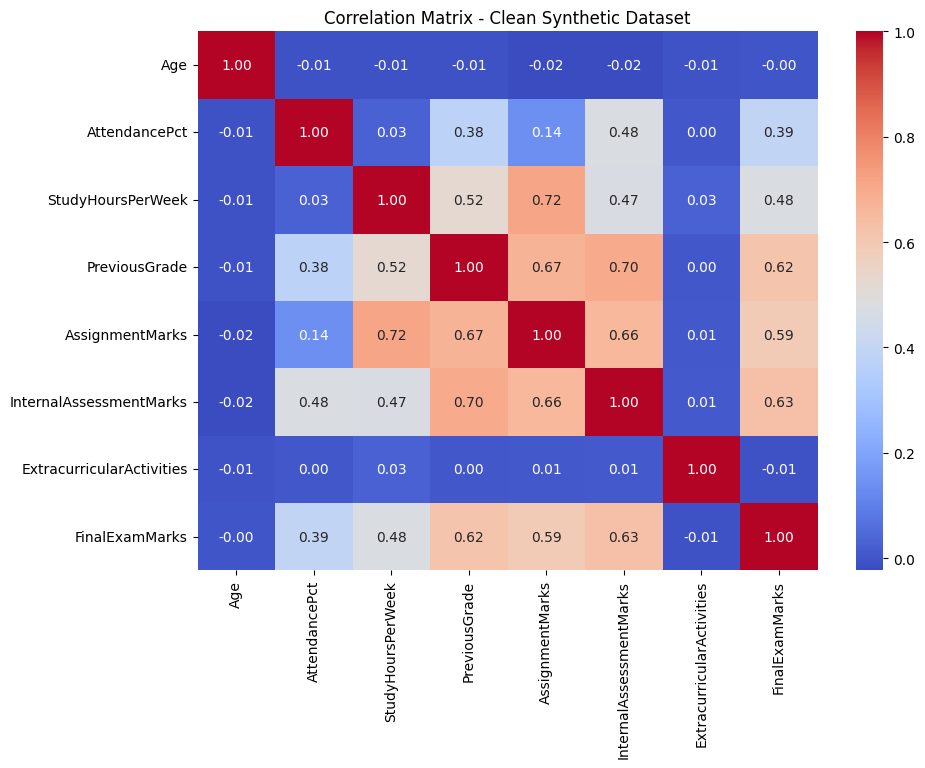

In [16]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df_synthetic.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix - Clean Synthetic Dataset")
plt.show()

making it realistically messy

In [17]:
df_raw = df_synthetic.copy()

Add missing values

In [18]:
np.random.seed(42)

missing_rates = {
    "AttendancePct": 0.03,
    "StudyHoursPerWeek": 0.03,
    "PreviousGrade": 0.02,
    "AssignmentMarks": 0.03,
    "InternalAssessmentMarks": 0.03,
    "ParentalSupport": 0.02
}

for col, rate in missing_rates.items():

    mask = np.random.random(len(df_raw)) < rate

    df_raw.loc[mask, col] = np.nan

adding invalid/outlier values

In [19]:
# Invalid attendance
invalid_attendance_idx = np.random.choice(
    df_raw.index,
    size=10,
    replace=False
)

df_raw.loc[
    invalid_attendance_idx,
    "AttendancePct"
] = np.random.choice(
    [105, 110, 120, -5],
    size=10
)

Study-hour errors:

In [20]:
invalid_study_idx = np.random.choice(
    df_raw.index,
    size=10,
    replace=False
)

df_raw.loc[
    invalid_study_idx,
    "StudyHoursPerWeek"
] = np.random.choice(
    [-5, -10, 60, 80],
    size=10
)

add a few duplicate rows

In [21]:
duplicate_rows = df_raw.sample(
    n=10,
    random_state=42
)

df_raw = pd.concat(
    [df_raw, duplicate_rows],
    ignore_index=True
)

In [22]:
print("Shape after introducing duplicates:", df_raw.shape)

Shape after introducing duplicates: (2010, 13)


introduce a few inconsistent categorical values

In [23]:
gender_indices = np.random.choice(
    df_raw.index,
    size=10,
    replace=False
)

df_raw.loc[
    gender_indices[:3],
    "Gender"
] = "male"

df_raw.loc[
    gender_indices[3:6],
    "Gender"
] = "female"

df_raw.loc[
    gender_indices[6:],
    "Gender"
] = "M"

save the raw synthetic dataset

In [24]:
raw_path = "/kaggle/working/student_performance_synthetic_raw_dataset.csv"

df_raw.to_csv(
    raw_path,
    index=False
)

print("Saved:", raw_path)

Saved: /kaggle/working/student_performance_synthetic_raw_dataset.csv


In [25]:
display(df_raw.head())
print("\nShape:", df_raw.shape)
print("\nMissing values:")
display(df_raw.isnull().sum())

,StudentID,Name,Age,Gender,AttendancePct,StudyHoursPerWeek,PreviousGrade,AssignmentMarks,InternalAssessmentMarks,OnlineClasses,ExtracurricularActivities,ParentalSupport,FinalExamMarks
0,STU10000,Allison Hill,23,Male,90.72,3.75,91.99,33.84,62.97,Yes,1,Medium,63.78
1,STU10001,Noah Rhodes,20,Female,85.40,18.33,71.25,42.83,48.57,Yes,0,Low,49.94
2,STU10002,Angie Henderson,21,Female,86.20,16.26,67.35,46.31,57.16,No,2,Medium,61.95
3,STU10003,Daniel Wagner,23,Female,61.61,6.29,67.47,40.79,44.76,No,1,Medium,43.33
4,STU10004,Cristian Santos,19,Female,92.54,20.83,67.44,62.36,69.36,No,0,Medium,66.48



Shape: (2010, 13)

Missing values:


StudentID                     0
Name                          0
Age                           0
Gender                        0
AttendancePct                59
StudyHoursPerWeek            62
PreviousGrade                36
AssignmentMarks              52
InternalAssessmentMarks      65
OnlineClasses                 0
ExtracurricularActivities     0
ParentalSupport              44
FinalExamMarks                0
dtype: int64